In [1]:
import cv2
import numpy as np
import os
import datetime
from skimage import io
import random
import matplotlib.pyplot as plt
import glob
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Activation, Dropout
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K
from keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")


2025-10-07 12:04:55.029444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759838695.247458      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759838695.304592      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


This code opens the webcam, displays the live video feed, and shows the camera’s frames per second (FPS).  
Press **‘q’** to quit and close the video window.


In [2]:
# Capturing video
# cap = cv2.VideoCapture(0)

# fps = int(cap.get(cv2.CAP_PROP_FPS))

# print("Frames per second using video.get(cv2.CAP_PROP_FPS) : {0}".format(fps))

# while cap.isOpened():
#     ret, frame = cap.read()
#     cv2.imshow('Captured Frame', frame)
#     if cv2.waitKey(1) == ord('q'):
#         break

#     keypress = cv2.waitKey(1) & 0xFF

# cap.release()
# cv2.destroyAllWindows()

This function separates the hand from the background.  
It compares the current frame with the background, applies a threshold to highlight movement,  
and returns the binary mask (`thresholded`) and the largest contour (`segmented`) representing the hand.


In [3]:
def segment(image, threshold = 25):
    global bg
    diff = cv2.absdiff(bg.astype('uint8'), image)
    thresholded = cv2.threshold(diff, threshold, 255,cv2.THRESHOLD_BINARY)[1]
    (cnts, _) = cv2.findContours(thresholded.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(cnts) == 0:
        return
    else:
        # maximum contour which is the hand
        segmented = max(cnts, key=cv2.contourArea)
        return (thresholded, segmented)

This code builds a CNN model for hand gesture recognition.  
It uses convolution, pooling, and dropout layers to extract features and prevent overfitting,  
then flattens the output and classifies it into 6 gesture categories using a softmax layer.


In [4]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100,120, 1))) 
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu')) # fully connected
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

optimiser = Adam() 
model.compile(optimizer=optimiser, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()

I0000 00:00:1759838707.906487      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759838707.907232      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 118, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 118, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 57, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41216)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,275,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,295,750 (20.20 MB)

 Trainable params: 5,295,558 (20.20 MB)

 Non-trainable params: 192 (768.00 B)

Loading Dataset Path
Sets the path to the hand gesture dataset, uses `glob` to get all subfolder paths (each representing a gesture class).


In [5]:
DATASET_PATH = '/kaggle/input/hand-gesture-recog-dataset/data'

dataset_path = os.path.join(DATASET_PATH, '*')
import glob
dataset_path = glob.glob(dataset_path)
dataset_path

['/kaggle/input/hand-gesture-recog-dataset/data/five',
 '/kaggle/input/hand-gesture-recog-dataset/data/thumbsdown',
 '/kaggle/input/hand-gesture-recog-dataset/data/ok',
 '/kaggle/input/hand-gesture-recog-dataset/data/blank',
 '/kaggle/input/hand-gesture-recog-dataset/data/fist',
 '/kaggle/input/hand-gesture-recog-dataset/data/thumbsup']

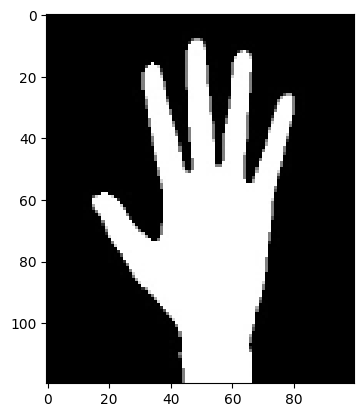

In [6]:
import cv2
image = cv2.imread('/kaggle/input/hand-gesture-recog-dataset/data/five/hand1(1015).jpg')
image = cv2.resize(image,(100, 120))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Image Loading and Label Creation  

This section loads and preprocesses the dataset for training:  

- Reads 1600 images per gesture category (6 total).  
- Converts each image to **grayscale** and resizes it to **100×120**.  
- Stores all processed images in `loaded_images`.  
- Creates **one-hot encoded labels** for each gesture in `outputVectors`.  


In [7]:
loaded_images = []

list_of_gestures = ['blank', 'ok', 'thumbsup', 'thumbsdown', 'fist', 'five']

for path in range(0, len(dataset_path)):
    dataset_path = "/kaggle/input/hand-gesture-recog-dataset/data/" + str(list_of_gestures[path])
    gesture_path = os.path.join(dataset_path, '*')
    import glob
    gest_path = glob.glob(gesture_path)
    k = 0
    for i in range(0, len(gest_path)):
        if k < 1600:
            image = cv2.imread(gest_path[i])
            gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            gray_image = cv2.resize(gray_image,(100, 120))
            loaded_images.append(gray_image)
        k=k+1
print(len(loaded_images))

outputVectors = []
for i in range(1, 1601):
    outputVectors.append([1, 0, 0, 0, 0, 0])

for i in range(1, 1601):
    outputVectors.append([0, 1, 0, 0, 0, 0])

for i in range(1, 1601):
    outputVectors.append([0, 0, 1, 0, 0, 0])
    
for i in range(1, 1601):
    outputVectors.append([0, 0, 0, 1, 0, 0])
    
for i in range(1, 1601):
    outputVectors.append([0, 0, 0, 0, 1, 0])

for i in range(1, 1601):
    outputVectors.append([0, 0, 0, 0, 0, 1])

print(len(outputVectors))

9600
9600


In [8]:
X = np.asarray(loaded_images)
y = np.asarray(outputVectors)
print(X.shape)
print(y.shape)

(9600, 120, 100)
(9600, 6)


## Splitting Data into Training and Testing Sets  

- Divides the dataset into **80% training** and **20% testing** using `train_test_split`.  
- Reshapes the images to **(100, 120, 1)** to match the CNN input format (grayscale).  
- Prints the shapes of `X_train` and `X_test` to confirm the split.  


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
X_train = X_train.reshape(X_train.shape[0], 100, 120, 1)
X_test = X_test.reshape(X_test.shape[0], 100, 120, 1)
print(X_train.shape)
print(X_test.shape)

(7680, 100, 120, 1)
(1920, 100, 120, 1)


In [10]:
model.fit(X_train, y_train,
          batch_size=128,
          epochs=10,
          verbose=1,
          validation_data=(X_test, y_test))
model.save("hand_gesture_recognition.h5")


Epoch 1/10


I0000 00:00:1759838746.371092     101 service.cc:148] XLA service 0x7840300022e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759838746.371749     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759838746.371770     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759838746.723933     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


 4/60 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - categorical_accuracy: 0.3311 - loss: 17.3976

I0000 00:00:1759838752.375265     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - categorical_accuracy: 0.6374 - loss: 6.4820 - val_categorical_accuracy: 0.7875 - val_loss: 0.4786
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.8192 - loss: 0.3920 - val_categorical_accuracy: 0.9010 - val_loss: 0.1965
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.8802 - loss: 0.2799 - val_categorical_accuracy: 0.9443 - val_loss: 0.1229
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.8995 - loss: 0.2260 - val_categorical_accuracy: 0.9839 - val_loss: 0.0455
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.9072 - loss: 0.2043 - val_categorical_accuracy: 0.9802 - val_loss: 0.0579
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.9137 - loss: 0.1895 - val_categorical_accuracy: 1.0000 - val_loss: 0.0152
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.9262 - loss: 0.1508 - val_c

In [11]:
[loss, acc] = model.evaluate(X_test,y_test,verbose=1)
print("Accuracy: " + str(acc))

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.9972 - loss: 0.0118
Accuracy: 0.9958333373069763


In [12]:
def _load_weights():
    try:
        model = load_model("hand_gesture_recog_model.h5")
        print(model.summary())
        return model
    except Exception as e:
        return None



    
def getPredictedClass(model):
    image = cv2.imread('Temp.png')
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_image = cv2.resize(gray_image, (100, 120))
    gray_image = gray_image.reshape(1, 100, 120, 1)

    prediction = model.predict_on_batch(gray_image)
    predicted_class = np.argmax(prediction)

    if predicted_class == 0:
        return "Blank"
    elif predicted_class == 1:
        return "OK"
    elif predicted_class == 2:
        return "Thumbs Up"
    elif predicted_class == 3:
        return "Thumbs Down"
    elif predicted_class == 4:
        return "Punch"
    elif predicted_class == 5:
        return "High Five"

if __name__ == "__main__":
    accumWeight = 0.5
    camera = cv2.VideoCapture(0)
    fps = int(camera.get(cv2.CAP_PROP_FPS))

    top, right, bottom, left = 10, 350, 225, 590
    num_frames = 0
    calibrated = False
    model = _load_weights()
    k = 0

    while True:
        grabbed, frame = camera.read()
        if not grabbed:
            break

        frame = cv2.resize(frame, (700, 700))
        frame = cv2.flip(frame, 1)
        clone = frame.copy()

        (height, width) = frame.shape[:2]
        roi = frame[top:bottom, right:left]

        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (7, 7), 0)

        if num_frames < 30:
            run_avg(gray, accumWeight)
            if num_frames == 1:
                print("[STATUS] please wait! calibrating...")
            elif num_frames == 29:
                print("[STATUS] calibration successful...")
        else:
            hand = segment(gray)
            if hand is not None:
                thresholded, segmented = hand
                cv2.drawContours(clone, [segmented + (right, top)], -1, (0, 0, 255))

                if k % (fps // 6) == 0:
                    cv2.imwrite('Temp.png', thresholded)
                    predictedClass = getPredictedClass(model)
                    cv2.putText(clone, str(predictedClass), (70, 45),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                cv2.imshow("Thresholded", thresholded)

        k += 1
        num_frames += 1
        cv2.rectangle(clone, (left, top), (right, bottom), (0, 255, 0), 2)
        cv2.imshow("Video Feed", clone)

        keypress = cv2.waitKey(1) & 0xFF
        if keypress == ord("q"):
            break

    camera.release()
    cv2.destroyAllWindows() 

[ WARN:0@707.087] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@707.088] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


error: OpenCV(4.12.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
